<a href="https://colab.research.google.com/github/EmptyRain75/mnist-ai-classifier/blob/main/notebooks/02_softmax_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Softmax Regression on MNIST

## Objective

In the previous stage, we implemented **Logistic Regression from scratch** for binary classification.

The goal of this notebook is to extend that idea to **multiclass classification** using **Softmax Regression** and apply it to the MNIST handwritten digit dataset.

MNIST contains images of digits from 0 to 9, so the model must distinguish between **10 classes** instead of only two.

The main transition is:

```text
Binary Logistic Regression
        ↓
Multiclass Softmax Regression


## Architecture

Softmax Regression keeps the same basic idea as Logistic Regression:

> A linear transformation produces scores, and an activation converts those scores into probabilities.

The difference is that the model must now produce one score for **each class**.

### Logistic Regression

For binary classification:

$$ z = x^T w + b $$

The model produces one logit:

$$ z \in \mathbb{R} $$

which is converted into one probability using the Sigmoid function:

$$ p = \sigma(z) $$

### Softmax Regression

For multiclass classification:

$$ z = xW + b $$

where:

- $x \in \mathbb{R}^{D}$ is one input sample
- $W \in \mathbb{R}^{D \times C}$ is the weight matrix
- $b \in \mathbb{R}^{C}$ is the bias vector
- $C$ is the number of classes

For MNIST:

$$ D = 784 $$

$$ C = 10 $$

Therefore:

$$ W \in \mathbb{R}^{784 \times 10} $$

and:

$$ z \in \mathbb{R}^{10} $$

The model now produces 10 logits:

$$ z = [z_0, z_1, \dots, z_9] $$

One for each digit class.

Softmax converts these logits into a probability distribution:

$$ [z_0,\dots,z_9] \rightarrow [p_0,\dots,p_9] $$

where:

$$ \sum_{k=0}^{9} p_k = 1 $$

The predicted class is the class with the highest probability:

$$ \hat{y} = \arg\max_k p_k $$

## Module 1 — MNIST Dataset

MNIST is a handwritten digit classification dataset containing grayscale images of digits from 0 to 9.

Each image has size:

$$ 28 \times 28 $$

So each image contains:

$$ 28 \times 28 = 784 $$

pixel values.

Our Softmax Regression model does not process the image as a 2D grid. Instead, each image will later be flattened into a 784-dimensional vector.

The classification task is:

$$ x \rightarrow y $$

where:

- $x$ is a handwritten digit image
- $y \in \{0,1,\dots,9\}$ is its class label

Unlike our previous binary Logistic Regression example, MNIST contains **10 possible classes**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


Label: 5
Image shape: (28, 28)


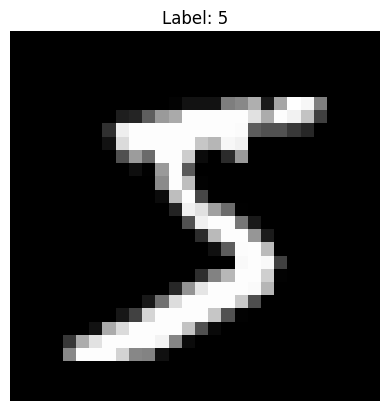

In [3]:
sample_index = 0

print("Label:", y_train[sample_index])
print("Image shape:", X_train[sample_index].shape)

plt.imshow(X_train[sample_index], cmap="gray")
plt.title(f"Label: {y_train[sample_index]}")
plt.axis("off")
plt.show()

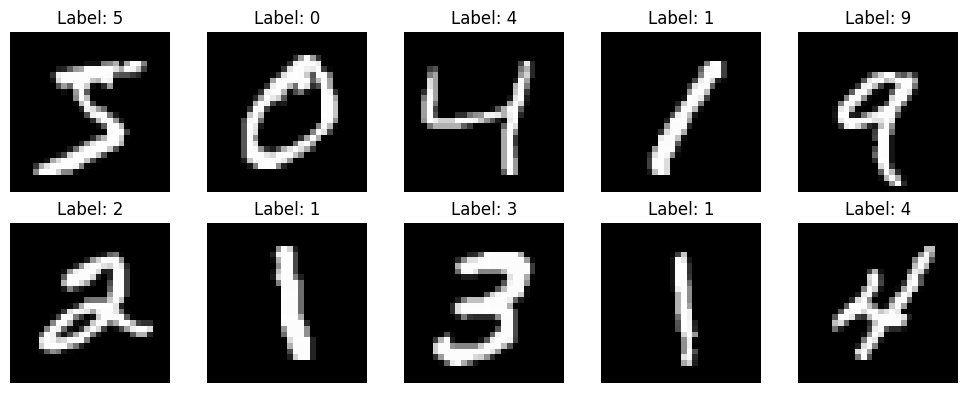

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

At this stage, each sample is still represented as a $28 \times 28$ image.

However, Softmax Regression expects an input vector.

Therefore, the next preprocessing step will transform:

$$ 28 \times 28 \rightarrow 784 $$

so each image becomes:

$$ x \in \mathbb{R}^{784} $$

The image information is not removed; the same 784 pixel values are simply rearranged into a one-dimensional vector.

## Module 2 — Preprocessing and Representation

Before training, the MNIST data needs to be converted into the representation expected by our linear model.

We will perform three preprocessing steps:

1. Create a validation set from the original training data.
2. Flatten each $28 \times 28$ image into a 784-dimensional vector.
3. Scale pixel values from $[0,255]$ to $[0,1]$.

### Train / Validation / Test Split

MNIST already provides:

- 60,000 training samples
- 10,000 test samples

We will reserve 10,000 samples from the original training set for validation.

The resulting datasets are:

```text
Training:   50,000 samples
Validation: 10,000 samples
Test:       10,000 samples

In [5]:
rng = np.random.default_rng(42)

indices = rng.permutation(len(X_train))

val_size = 10000

val_indices = indices[:val_size]
train_indices = indices[val_size:]

X_val = X_train[val_indices]
y_val = y_train[val_indices]

X_train = X_train[train_indices]
y_train = y_train[train_indices]

In [6]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (50000, 28, 28) (50000,)
Validation: (10000, 28, 28) (10000,)
Test: (10000, 28, 28) (10000,)


### Flattening

Softmax Regression is a linear model, so it expects each sample to be represented as a feature vector.

Currently one MNIST image has shape:

$$ (28,28) $$

We flatten it into:

$$ (784,) $$

Therefore, for a dataset containing $N$ samples:

$$ X \in \mathbb{R}^{N \times 784} $$

For the training set:

$$ X_{\text{train}} \in \mathbb{R}^{50000 \times 784} $$

Each pixel becomes one input feature.

Unlike a CNN, Softmax Regression does not explicitly preserve the two-dimensional spatial structure of the image.

In [7]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [8]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (50000, 784)
X_val: (10000, 784)
X_test: (10000, 784)


### Pixel Scaling

MNIST pixels are stored as integers between:

$$ 0 \leq x \leq 255 $$

where:

- $0$ represents black
- $255$ represents white

We scale them into:

$$ 0 \leq x \leq 1 $$

using:

$$ x_{\text{scaled}} = \frac{x}{255} $$

This keeps the input values small and gives gradient descent a more convenient numerical scale.

In the previous Logistic Regression experiment, we standardized the synthetic features because they were arbitrary continuous values.

For MNIST, the pixels already have a known fixed range, so simple $[0,1]$ scaling is sufficient for our current model.

In [9]:
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [10]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

print("X_train dtype:", X_train.dtype)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
X_train dtype: float32


### Final Representation

After preprocessing, one MNIST sample has the form:

$$ x = [x_1,x_2,\dots,x_{784}] $$

with:

$$ x_j \in [0,1] $$

Our datasets now have:

```text
X_train : (50000, 784)
X_val   : (10000, 784)
X_test  : (10000, 784)

## Module 3 — Multiclass Linear Model

In binary Logistic Regression, the linear model produces a single logit:

$$ z = x^T w + b $$

where:

- $x \in \mathbb{R}^{D}$
- $w \in \mathbb{R}^{D}$
- $b \in \mathbb{R}$

For MNIST, however, we have 10 possible classes.

So instead of producing one score, the model must produce **10 scores**:

$$ z = [z_0,z_1,\dots,z_9] $$

Each $z_k$ represents the model's score for class $k$.

To produce 10 outputs, the single weight vector $w$ becomes a weight matrix:

$$ W \in \mathbb{R}^{D \times C} $$

where:

- $D = 784$ input features
- $C = 10$ classes

Therefore:

$$ W \in \mathbb{R}^{784 \times 10} $$

The bias also becomes a vector:

$$ b \in \mathbb{R}^{10} $$

The linear transformation becomes:

$$ z = xW + b $$

### What Does the Weight Matrix Mean?

The weight matrix can be viewed as 10 separate weight vectors stored side by side:

$$ W = [w_0\;w_1\;\dots\;w_9] $$

where each:

$$ w_k \in \mathbb{R}^{784} $$

belongs to one class.

For example:

- $w_0$ contains the weights used to score how much an image looks like digit 0
- $w_1$ scores digit 1
- $w_2$ scores digit 2
- ...
- $w_9$ scores digit 9

For one input image $x$, the score for class $k$ is:

$$ z_k = x^T w_k + b_k $$

So the full linear layer is equivalent to computing:

$$ z_0 = x^T w_0 + b_0 $$

$$ z_1 = x^T w_1 + b_1 $$

$$ \vdots $$

$$ z_9 = x^T w_9 + b_9 $$

and combining them into:

$$ z = [z_0,z_1,\dots,z_9] $$

### Batch Form

For the full dataset:

$$ X \in \mathbb{R}^{N \times 784} $$

and:

$$ W \in \mathbb{R}^{784 \times 10} $$

Therefore:

$$ Z = XW + b $$

has shape:

$$ Z \in \mathbb{R}^{N \times 10} $$

Each row of $Z$ belongs to one sample.

Each column belongs to one class.

In [11]:
n_features = X_train.shape[1]
n_classes = 10

W = np.zeros((n_features, n_classes))
b = np.zeros(n_classes)

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: (784, 10)
b shape: (10,)


In [12]:
Z = X_train @ W + b

print("Z shape:", Z.shape)
print("First sample logits:", Z[0])

Z shape: (50000, 10)
First sample logits: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Initial Logits

Because both $W$ and $b$ are initialized to zero:

$$ Z = XW + b = 0 $$

So initially, every class receives the same score.

At this stage, these values are only **logits**.

They are not yet probabilities.

For example, logits could eventually look like:

```text
[1.2, -0.4, 2.8, 0.1, -1.3, 0.7, 3.5, -0.8, 1.0, 0.2]

## Module 4 — Softmax Function

The linear model produces one logit for each class:

$$ z = [z_0,z_1,\dots,z_9] $$

These logits are arbitrary real numbers.

For example:

```text
[1.2, -0.4, 2.8, 0.1, -1.3, 0.7, 3.5, -0.8, 1.0, 0.2]

### Softmax Definition

For class $k$, Softmax is defined as:

$$ p_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}} $$

where:

- $z_k$ is the logit for class $k$
- $C$ is the number of classes
- $p_k$ is the predicted probability of class $k$

For MNIST:

$$ C = 10 $$

so each image produces:

$$ p = [p_0,p_1,\dots,p_9] $$

with:

$$ 0 < p_k < 1 $$

and:

$$ \sum_{k=0}^{9} p_k = 1 $$

### Why Exponentials?

Softmax first applies the exponential function:

$$ e^{z_k} $$

This has two useful properties.

First, exponentials are always positive:

$$ e^{z_k} > 0 $$

so every class receives a positive value.

Second, larger logits produce larger exponential values.

For example:

$$ e^1 \approx 2.72 $$

$$ e^2 \approx 7.39 $$

$$ e^3 \approx 20.09 $$

Therefore, a class with a larger logit receives more probability mass.

Softmax then divides each exponential by the sum of all exponentials:

$$ p_k = \frac{e^{z_k}}{\sum_j e^{z_j}} $$

This normalization forces all probabilities to sum to 1.

### Example

Suppose a three-class model produces:

$$ z = [1,2,3] $$

Exponentiating gives approximately:

$$ e^z = [2.72,7.39,20.09] $$

Their sum is:

$$ 2.72 + 7.39 + 20.09 = 30.20 $$

So Softmax produces approximately:

$$ p = [0.09,0.24,0.67] $$

The third class has the largest logit, so it also receives the largest probability.

Importantly, Softmax does not consider each class independently.

Each probability depends on **all logits** because every class shares the same denominator.

In [13]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

In [14]:
example_logits = np.array([1.0, 2.0, 3.0])

example_probs = softmax(example_logits)

print("Logits:", example_logits)
print("Probabilities:", example_probs)
print("Sum:", example_probs.sum())

Logits: [1. 2. 3.]
Probabilities: [0.09003057 0.24472847 0.66524096]
Sum: 1.0


### Numerical Stability

The mathematical Softmax formula is correct, but implementing it directly can cause numerical problems.

Consider a very large logit:

$$ z = 1000 $$

Computing:

$$ e^{1000} $$

produces a number too large for normal floating-point representation.

This can cause overflow and result in values such as: $inf$

In [15]:
large_logits = np.array([1000.0, 1001.0, 1002.0])

print(np.exp(large_logits))

[inf inf inf]


/tmp/ipykernel_4942/1732482723.py:3: RuntimeWarning: overflow encountered in exp
  print(np.exp(large_logits))


### Stable Softmax

Softmax has an important property: adding or subtracting the same constant from every logit does not change the final probabilities.

For any constant $c$:

$$ \text{softmax}(z) = \text{softmax}(z-c) $$

Therefore, we can subtract the largest logit:

$$ z_{\text{stable}} = z - \max(z) $$

The largest adjusted logit becomes:

$$ 0 $$

so its exponential becomes:

$$ e^0 = 1 $$

and all other adjusted logits are less than or equal to zero.

This prevents extremely large exponential values.

In [16]:
def softmax(z):
    z_shifted = z - np.max(z)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

In [17]:
large_logits = np.array([1000.0, 1001.0, 1002.0])

probs = softmax(large_logits)

print("Probabilities:", probs)
print("Sum:", probs.sum())

Probabilities: [0.09003057 0.24472847 0.66524096]
Sum: 0.9999999999999999


In [18]:
neg_large_logits = np.array([-1000.0, -1001.0, -1002.0])

probs = softmax(neg_large_logits)

print("Probabilities:", probs)
print("Sum:", probs.sum())

Probabilities: [0.66524096 0.24472847 0.09003057]
Sum: 0.9999999999999999


### Batch Softmax

For a batch:

$$ Z \in \mathbb{R}^{N \times C} $$

Softmax is applied independently to each sample.

Therefore, for every row $i$:

$$ p_{ik} = \frac{e^{z_{ik}}}{\sum_j e^{z_{ij}}} $$

The result has the same shape:

$$ P \in \mathbb{R}^{N \times C} $$

and every row satisfies:

$$ \sum_k P_{ik} = 1 $$

In [19]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)

    exp_Z = np.exp(Z_shifted)

    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [20]:
P = softmax(Z)

print("Z shape:", Z.shape)
print("P shape:", P.shape)

print("\nFirst sample logits:")
print(Z[0])

print("\nFirst sample probabilities:")
print(P[0])

print("\nProbability sum:")
print(P[0].sum())

Z shape: (50000, 10)
P shape: (50000, 10)

First sample logits:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First sample probabilities:
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

Probability sum:
1.0


### Initial Prediction

At initialization:

$$ z_0 = z_1 = \dots = z_9 = 0 $$

Therefore:

$$ e^{z_k} = 1 $$

for every class.

Softmax therefore gives:

$$ p_k = \frac{1}{10} = 0.1 $$

The model initially assigns equal probability to every digit because it has not learned anything yet.

During training, the weights will change, causing different classes to receive different logits and therefore different probabilities.

## Module 5 — Multiclass Cross Entropy

In Logistic Regression, the model produces one probability and uses **Binary Cross Entropy**.

Softmax Regression instead produces one probability for every class:

$$ P = [p_0, p_1, \dots, p_9] $$

For MNIST, there are 10 possible classes.

The loss therefore needs to compare this probability distribution with the correct digit.

Before defining the loss, we first need a convenient mathematical representation of the target label.

### One-Hot Encoding

MNIST labels are currently stored as integer class indices.

For example, if the correct digit is 3:

$$ y = 3 $$

For multiclass mathematics, it is useful to represent the label as a vector with one element for each class.

The correct class is represented by 1 and every incorrect class by 0.

For example:

$$ y = 3 $$

becomes:

$$ Y = [0,0,0,1,0,0,0,0,0,0] $$

Similarly:

$$ y = 0 $$

becomes:

$$ Y = [1,0,0,0,0,0,0,0,0,0] $$

and:

$$ y = 7 $$

becomes:

$$ Y = [0,0,0,0,0,0,0,1,0,0] $$

This representation is called **one-hot encoding**.

For one sample:

$$ Y \in \mathbb{R}^{10} $$

For a batch containing $N$ samples:

$$ Y \in \mathbb{R}^{N \times 10} $$

The one-hot representation will be especially useful later when deriving the Softmax Regression gradient.

In [21]:
def one_hot_encode(y, n_classes=10):
    return np.eye(n_classes)[y]

In [22]:
example_labels = np.array([3, 0, 7])

example_one_hot = one_hot_encode(example_labels)

print("Labels:")
print(example_labels)

print("\nOne-hot encoded labels:")
print(example_one_hot)

Labels:
[3 0 7]

One-hot encoded labels:
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


### Multiclass Cross Entropy

For one sample, Multiclass Cross Entropy is defined as:

$$ L = -\sum_{k=0}^{C-1} y_k \log(p_k) $$

where:

- $C$ is the number of classes
- $y_k$ is the target value for class $k$
- $p_k$ is the predicted probability for class $k$

Because $Y$ is one-hot encoded, only the correct class has $y_k = 1$.

Every other class has:

$$ y_k = 0 $$

so their terms disappear from the sum.

If the correct class is $c$, the loss simplifies to:

$$ L = -\log(p_c) $$

Therefore, Cross Entropy measures how much probability the model assigned to the correct class.

A high correct-class probability produces a small loss.

A low correct-class probability produces a large loss.

### Example

Suppose the correct digit is 2.

The target is:

$$ Y = [0,0,1,0,0,0,0,0,0,0] $$

Suppose the model predicts:

$$ P = [0.05,0.10,0.70,0.05,0.03,0.02,0.01,0.01,0.02,0.01] $$

The correct class is class 2, so only $p_2$ contributes to the loss:

$$ L = -\log(0.70) $$

$$ L \approx 0.357 $$

If the model instead assigned only $0.01$ probability to the correct class:

$$ L = -\log(0.01) $$

$$ L \approx 4.605 $$

Therefore, Cross Entropy strongly penalizes predictions that assign very little probability to the correct class.

In [23]:
good_probability = 0.70
bad_probability = 0.01

good_loss = -np.log(good_probability)
bad_loss = -np.log(bad_probability)

print("Good prediction loss:", good_loss)
print("Bad prediction loss:", bad_loss)

Good prediction loss: 0.35667494393873245
Bad prediction loss: 4.605170185988091


### Cross Entropy for a Batch

For $N$ samples, the average Cross Entropy loss is:

$$ L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=0}^{C-1} y_{ik}\log(p_{ik}) $$

Since each target is one-hot encoded, only the correct class contributes for each sample.

Therefore, this can also be written as:

$$ L = -\frac{1}{N}\sum_{i=1}^{N}\log(p_{i,y_i}) $$

Although one-hot encoding is useful for understanding the mathematics, we do not actually need to create the complete one-hot matrix just to calculate the loss.

Since the original labels already contain the correct class index, we can directly select the correct-class probability from each row of $P$.

In [24]:
def cross_entropy(y, P):
    n_samples = len(y)

    correct_class_probs = P[np.arange(n_samples), y]

    epsilon = 1e-12
    correct_class_probs = np.clip(correct_class_probs, epsilon, 1.0)

    return -np.mean(np.log(correct_class_probs))

### Selecting the Correct-Class Probability

The expression `P[np.arange(n_samples), y]` selects one probability from each sample.

For example, if the labels are:

`y = [5, 0, 4]`

then NumPy selects:

`P[0, 5]`  
`P[1, 0]`  
`P[2, 4]`

These are exactly the probabilities assigned to the correct classes.

The clipping step prevents numerical problems with:

$$ \log(0) $$

which is undefined.

## Module 6 — Gradients / Backpropagation

The forward pass is now:

$$ X \rightarrow Z = XW + b \rightarrow P = \text{softmax}(Z) \rightarrow L $$

where:

- $X \in \mathbb{R}^{N \times D}$
- $W \in \mathbb{R}^{D \times C}$
- $b \in \mathbb{R}^{C}$
- $Z \in \mathbb{R}^{N \times C}$
- $P \in \mathbb{R}^{N \times C}$

To train the model, we need the gradients:

$$ \frac{\partial L}{\partial W} $$

and:

$$ \frac{\partial L}{\partial b} $$

As in Logistic Regression, we first find the gradient with respect to the logits $Z$, then propagate it backward through the linear transformation.

### Gradient of Softmax + Cross Entropy

For one sample, the Cross Entropy loss is:

$$ L = -\sum_{k=0}^{C-1} y_k \log(p_k) $$

and Softmax is:

$$ p_k = \frac{e^{z_k}}{\sum_j e^{z_j}} $$

Although differentiating Softmax by itself involves interactions between all classes, combining Softmax with Cross Entropy produces a very simple result:

$$ \frac{\partial L}{\partial z_k} = p_k - y_k $$

For the complete output vector:

$$ \frac{\partial L}{\partial z} = p - y $$

For a batch:

$$ \frac{\partial L}{\partial Z} = P - Y $$

where $Y$ is the one-hot encoded target matrix.

This is the multiclass version of the Logistic Regression result:

$$ \frac{\partial L}{\partial z} = p-y $$

The structure is therefore almost identical: the gradient measures the difference between the predicted probabilities and the target probabilities.

### Interpreting $P - Y$

Suppose the correct class is digit 2.

The target is:

$$ Y = [0,0,1,0] $$

and suppose the model predicts:

$$ P = [0.10,0.20,0.60,0.10] $$

Then:

$$ P-Y = [0.10,0.20,-0.40,0.10] $$

For incorrect classes, the gradient is positive.

Gradient descent will therefore reduce their logits.

For the correct class, the gradient is negative:

$$ 0.60 - 1 = -0.40 $$

Gradient descent will therefore increase the correct-class logit.

This pushes the probability distribution toward the correct class.

In [25]:
example_P = np.array([
    [0.10, 0.20, 0.60, 0.10]
])

example_y = np.array([2])

example_Y = one_hot_encode(example_y, n_classes=4)

example_dZ = example_P - example_Y

print("Predicted probabilities:")
print(example_P)

print("\nTarget:")
print(example_Y)

print("\nP - Y:")
print(example_dZ)

Predicted probabilities:
[[0.1 0.2 0.6 0.1]]

Target:
[[0. 0. 1. 0.]]

P - Y:
[[ 0.1  0.2 -0.4  0.1]]


### Gradient with Respect to the Weights

The linear transformation is:

$$ Z = XW + b $$

We already know from the Logistic Regression stage that the gradient through a linear layer depends on the input and the upstream error.

For Softmax Regression:

$$ dZ = P-Y $$

For a batch of $N$ samples, the weight gradient is:

$$ dW = \frac{1}{N}X^T dZ $$

Substituting $dZ$:

$$ dW = \frac{1}{N}X^T(P-Y) $$

The dimensions are:

$$ X^T \in \mathbb{R}^{D \times N} $$

$$ P-Y \in \mathbb{R}^{N \times C} $$

therefore:

$$ dW \in \mathbb{R}^{D \times C} $$

which matches the shape of:

$$ W \in \mathbb{R}^{D \times C} $$

### Gradient with Respect to the Bias

The bias is added to every sample:

$$ Z = XW + b $$

Therefore, the bias gradient is the average error across the batch:

$$ db = \frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i) $$

Since there is one bias for each class:

$$ db \in \mathbb{R}^{C} $$

For MNIST:

$$ db \in \mathbb{R}^{10} $$

In [26]:
def compute_gradients(X, y, P, n_classes=10):
    n_samples = X.shape[0]

    Y = one_hot_encode(y, n_classes)

    dZ = P - Y

    dW = (X.T @ dZ) / n_samples
    db = np.mean(dZ, axis=0)

    return dW, db

### Gradient Shapes

The gradient function follows the same backpropagation structure as Logistic Regression, but now each sample has one error value for every class.

The important shapes are:

| Variable | Shape |
|---|---|
| $X$ | $(N,784)$ |
| $P$ | $(N,10)$ |
| $Y$ | $(N,10)$ |
| $dZ$ | $(N,10)$ |
| $dW$ | $(784,10)$ |
| $db$ | $(10,)$ |

The parameter gradients have exactly the same shapes as the parameters they update:

$$ dW \leftrightarrow W $$

$$ db \leftrightarrow b $$

In [27]:
dW, db = compute_gradients(
    X_train,
    y_train,
    P,
    n_classes=10
)

print("dW shape:", dW.shape)
print("db shape:", db.shape)

print("\nFirst few bias gradients:")
print(db[:5])

dW shape: (784, 10)
db shape: (10,)

First few bias gradients:
[ 0.0017  -0.012    0.0004  -0.0014   0.00262]


### Numerical Gradient Check

The gradients above were derived analytically:

$$ dW = \frac{1}{N}X^T(P-Y) $$

$$ db = \frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i) $$

To verify that the implementation is correct, we can compare an analytical gradient with a numerical approximation.

For one parameter $\theta$, the numerical gradient is:

$$ \frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon} $$

This is called the **central difference approximation**.

If the analytical and numerical gradients are very close, our backpropagation implementation is likely correct.

In [28]:
X_check = X_train[:5]
y_check = y_train[:5]

W_check = np.random.randn(784, 10) * 0.01
b_check = np.zeros(10)

Z_check = X_check @ W_check + b_check
P_check = softmax(Z_check)

dW_check, db_check = compute_gradients(
    X_check,
    y_check,
    P_check,
    n_classes=10
)

In [29]:
epsilon = 1e-5

row = 0
col = 0

W_plus = W_check.copy()
W_minus = W_check.copy()

W_plus[row, col] += epsilon
W_minus[row, col] -= epsilon

P_plus = softmax(X_check @ W_plus + b_check)
P_minus = softmax(X_check @ W_minus + b_check)

loss_plus = cross_entropy(y_check, P_plus)
loss_minus = cross_entropy(y_check, P_minus)

numerical_gradient = (
    loss_plus - loss_minus
) / (2 * epsilon)

analytical_gradient = dW_check[row, col]

print("Analytical gradient:", analytical_gradient)
print("Numerical gradient :", numerical_gradient)
print("Difference         :", abs(
    analytical_gradient - numerical_gradient
))

Analytical gradient: 0.0
Numerical gradient : 0.0
Difference         : 0.0


In [30]:
epsilon = 1e-5

index = 0

b_plus = b_check.copy()
b_minus = b_check.copy()

b_plus[index] += epsilon
b_minus[index] -= epsilon

P_plus = softmax(X_check @ W_check + b_plus)
P_minus = softmax(X_check @ W_check + b_minus)

loss_plus = cross_entropy(y_check, P_plus)
loss_minus = cross_entropy(y_check, P_minus)

numerical_db = (
    loss_plus - loss_minus
) / (2 * epsilon)

analytical_db = db_check[index]

print("Analytical db:", analytical_db)
print("Numerical db :", numerical_db)
print("Difference   :", abs(analytical_db - numerical_db))

Analytical db: 0.1206370888298256
Numerical db : 0.12063708882958933
Difference   : 2.3626933742804113e-13


Uh bias looks fine but weights are a bit off let's try:

In [31]:
epsilon = 1e-5

# Choose a weight whose analytical gradient is clearly non-zero
row, col = np.unravel_index(
    np.argmax(np.abs(dW_check)),
    dW_check.shape
)

print("Checking weight:", (row, col))
print("Input pixel values:", X_check[:, row])

W_plus = W_check.copy()
W_minus = W_check.copy()

W_plus[row, col] += epsilon
W_minus[row, col] -= epsilon

P_plus = softmax(X_check @ W_plus + b_check)
P_minus = softmax(X_check @ W_minus + b_check)

loss_plus = cross_entropy(y_check, P_plus)
loss_minus = cross_entropy(y_check, P_minus)

numerical_gradient = (
    loss_plus - loss_minus
) / (2 * epsilon)

analytical_gradient = dW_check[row, col]

print("\nAnalytical gradient:", analytical_gradient)
print("Numerical gradient :", numerical_gradient)
print(
    "Difference         :",
    abs(analytical_gradient - numerical_gradient)
)

Checking weight: (np.int64(708), np.int64(7))
Input pixel values: [0.99215686 0.9098039  0.         0.         0.        ]

Analytical gradient: -0.3465962033979547
Numerical gradient : -0.3465962034043812
Difference         : 6.426470466891487e-12


### Interpreting the Result

both looks right now, diff is less than 10^-7 so the formula is fine

## Module 7 — Optimization and Training

The optimization process is the same as in Logistic Regression.

We use Gradient Descent to update the parameters in the direction that reduces the loss:

$$ W \leftarrow W - \eta dW $$

$$ b \leftarrow b - \eta db $$

where:

- $\eta$ is the learning rate
- $dW$ is the gradient of the loss with respect to $W$
- $db$ is the gradient of the loss with respect to $b$

The difference is only in the parameter shapes:

$$ W \in \mathbb{R}^{784 \times 10} $$

$$ b \in \mathbb{R}^{10} $$

The training loop therefore keeps the same overall structure:

1. Compute logits.
2. Apply Softmax.
3. Compute Cross Entropy loss.
4. Compute gradients.
5. Update parameters.
6. Repeat.

In [32]:
def update_parameters(W, b, dW, db, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db

    return W, b

### Training Loop

For each iteration, the model performs a complete forward and backward pass.

The forward pass is:

$$ X \rightarrow Z \rightarrow P \rightarrow L $$

The backward pass is:

$$ L \rightarrow dZ \rightarrow dW, db $$

Then Gradient Descent updates the parameters.

We will store the loss after each iteration so we can observe whether the model is learning.

In [33]:
def train_softmax_regression(
    X,
    y,
    n_classes=10,
    learning_rate=0.1,
    n_iterations=1000
):
    n_features = X.shape[1]

    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)

    loss_history = []

    for iteration in range(n_iterations):
        # Forward pass
        Z = X @ W + b
        P = softmax(Z)

        # Loss
        loss = cross_entropy(y, P)
        loss_history.append(loss)

        # Backward pass
        dW, db = compute_gradients(
            X,
            y,
            P,
            n_classes
        )

        # Parameter update
        W, b = update_parameters(
            W,
            b,
            dW,
            db,
            learning_rate
        )

    return W, b, loss_history

### Initial Training Experiment

We will first train the model with a fixed learning rate and observe the loss.

At this stage, the goal is not yet to find the best hyperparameters.

We only want to verify that:

- the loss decreases
- the model parameters update correctly
- the Softmax Regression model learns from MNIST

In [34]:
W, b, loss_history = train_softmax_regression(
    X_train,
    y_train,
    n_classes=10,
    learning_rate=0.1,
    n_iterations=1000
)

# training took 9 mins cpu

In [35]:
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

Initial loss: 2.3025850929940455
Final loss: 0.34431023595098625


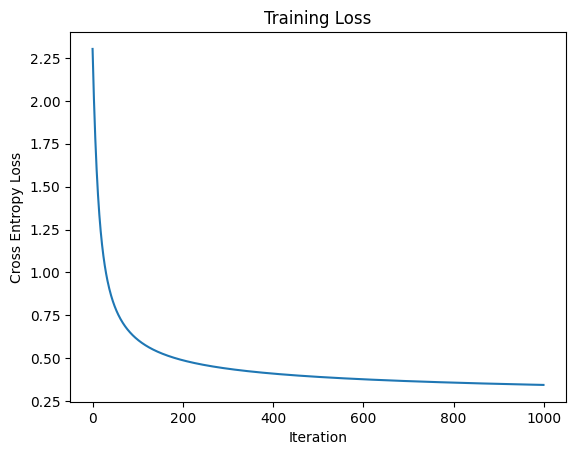

In [36]:
plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("Cross Entropy Loss")
plt.title("Training Loss")

plt.show()

### Training Loss

At initialization, the expected loss is approximately:

$$ \log(10) \approx 2.3026 $$

As training progresses, Gradient Descent adjusts the class weight vectors and biases.

A decreasing loss indicates that the model is assigning progressively higher probability to the correct classes.

## Module 8 — Evaluation

After training, we evaluate how well the model classifies unseen MNIST images.

The evaluation process is:

1. Compute logits.
2. Convert logits to probabilities with Softmax.
3. Select the class with the highest probability.
4. Compare predictions with the true labels.

Unlike binary Logistic Regression, we do not use a threshold such as 0.5.

For multiclass classification, the predicted class is:

$$ \hat{y} = \arg\max_k p_k $$

where $p_k$ is the predicted probability for class $k$.

In [37]:
def predict_proba(X, W, b):
    Z = X @ W + b
    return softmax(Z)


def predict(X, W, b):
    P = predict_proba(X, W, b)
    return np.argmax(P, axis=1)

### Prediction with `argmax`

For each sample, Softmax produces a probability vector:

$$ P = [p_0,p_1,\dots,p_9] $$

For example:

$$ P = [0.01,0.02,0.03,0.80,0.02,0.04,0.01,0.03,0.02,0.02] $$

The highest probability is:

$$ p_3 = 0.80 $$

so:

$$ \hat{y} = 3 $$

In NumPy, `np.argmax(P, axis=1)` selects the class index with the highest probability for every sample.

In [38]:
y_train_pred = predict(X_train, W, b)
y_val_pred = predict(X_val, W, b)
y_test_pred = predict(X_test, W, b)

In [39]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [40]:
train_accuracy = accuracy(y_train, y_train_pred)
val_accuracy = accuracy(y_val, y_val_pred)
test_accuracy = accuracy(y_test, y_test_pred)

print("Training accuracy  :", train_accuracy)
print("Validation accuracy:", val_accuracy)
print("Test accuracy      :", test_accuracy)

Training accuracy  : 0.90494
Validation accuracy: 0.9007
Test accuracy      : 0.9098


### Train, Validation, and Test Accuracy

We evaluate three datasets:

- **Training accuracy** measures performance on the data used to update the parameters.
- **Validation accuracy** measures performance on unseen data used during experimentation.
- **Test accuracy** measures final generalization performance.

The validation and test results are especially important because they show whether the model learned patterns that generalize beyond the training samples.

### Confusion Matrix

Accuracy tells us how often the model is correct, but it does not show which digits are being confused.

For multiclass classification, we use a confusion matrix.

The entry at row $i$, column $j$ counts how many samples with true class $i$ were predicted as class $j$.

For MNIST, the confusion matrix has shape:

$$ 10 \times 10 $$

The diagonal represents correct predictions.

Values outside the diagonal represent classification errors.

In [41]:
def confusion_matrix(y_true, y_pred, n_classes=10):
    matrix = np.zeros((n_classes, n_classes), dtype=int)

    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[true_label, predicted_label] += 1

    return matrix

In [42]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[ 957    0    3    2    0    5    9    1    3    0]
 [   0 1102    2    3    1    2    4    1   20    0]
 [  11    8  897   15   15    1   16   18   42    9]
 [   5    1   20  907    1   29    3   13   20   11]
 [   1    3    6    1  911    1   10    1    8   40]
 [  11    4    5   41   11  751   17   11   32    9]
 [  15    3    5    2   13   16  901    1    2    0]
 [   3   19   25    5   11    0    0  929    3   33]
 [   9    9    8   26    8   21   14   15  850   14]
 [  11    8    5   11   43   10    0   22    6  893]]


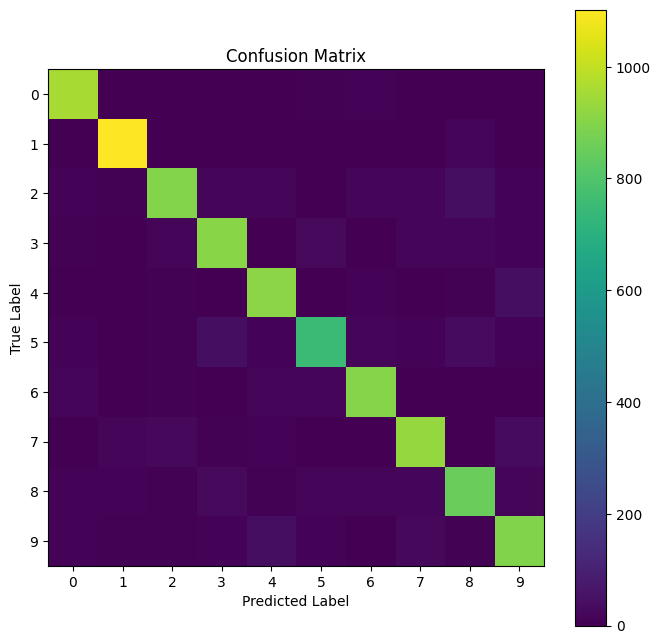

In [43]:
plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()

plt.show()

### Inspecting Predictions

Metrics summarize model performance, but viewing individual predictions helps us understand what the model is actually doing.

Because the images were flattened for training, we reshape them back to $28 \times 28$ only for visualization.

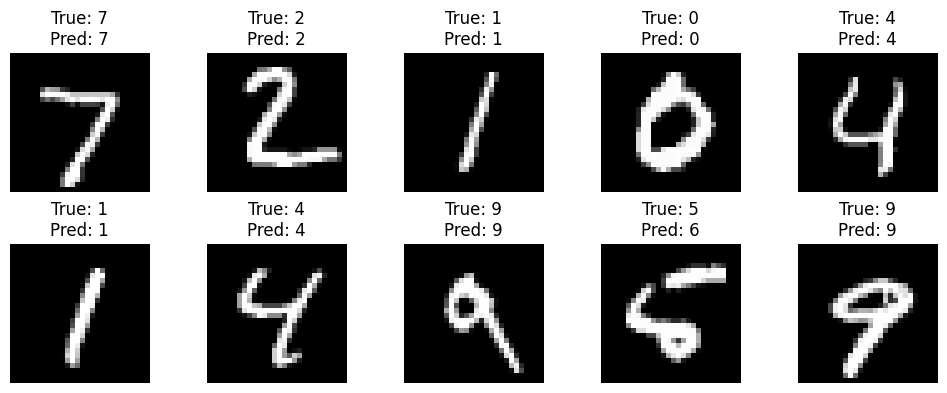

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image = X_test[i].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"True: {y_test[i]}\nPred: {y_test_pred[i]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

The 5 is devious, you'd be compelled to cut it some slack too.

In [45]:
incorrect_indices = np.where(
    y_test_pred != y_test
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 902


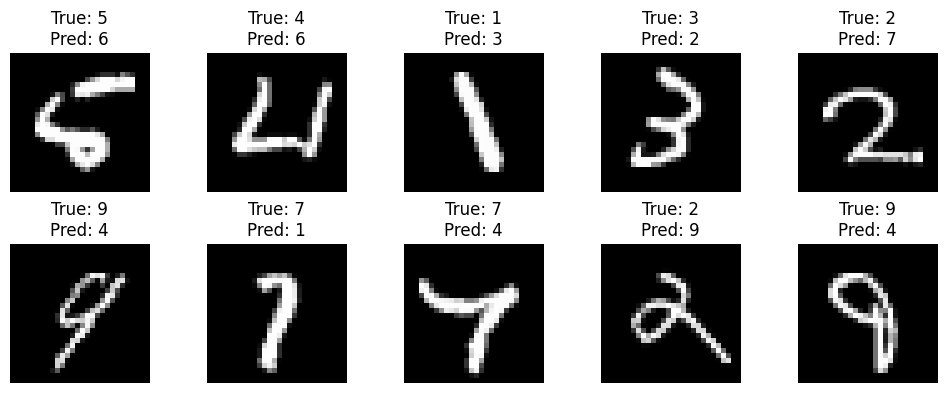

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    index = incorrect_indices[i]

    image = X_test[index].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"True: {y_test[index]}\nPred: {y_test_pred[index]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

Softmax Regression can successfully classify many MNIST digits using only a linear decision model.

However, some handwritten digits are difficult to separate using only linear boundaries.

By inspecting the confusion matrix and incorrect predictions, we can identify which digit classes are commonly confused.

These limitations will become important later when we introduce models with greater representational capacity, such as an MLP or CNN.

## Module 9 — Experiments and Model Selection

The previous modules verified that Softmax Regression can learn MNIST.

Now we test how training choices affect performance.

We will compare:

1. Different learning rates
2. Different numbers of iterations
3. Full-batch versus mini-batch training

The validation set will be used to compare configurations.

The test set will not be used for selecting hyperparameters.

This prevents us from indirectly tuning the model to the test data.

### Experiment 1 — Learning Rate

The learning rate controls the size of each gradient descent update:

$$ W \leftarrow W - \eta dW $$

A learning rate that is too small may learn very slowly.

A learning rate that is too large may make training unstable.

We will compare several values while keeping the number of iterations fixed.

In [47]:
%%time

learning_rates = [0.01, 0.05, 0.1, 0.5]

lr_results = []

for lr in learning_rates:
    W_exp, b_exp, loss_history_exp = train_softmax_regression(
        X_train,
        y_train,
        n_classes=10,
        learning_rate=lr,
        n_iterations=300
    )

    y_val_pred_exp = predict(X_val, W_exp, b_exp)

    val_acc = accuracy(y_val, y_val_pred_exp)

    lr_results.append({
        "learning_rate": lr,
        "val_accuracy": val_acc,
        "final_loss": loss_history_exp[-1],
        "W": W_exp,
        "b": b_exp
    })

    print(
        f"Learning rate: {lr} | "
        f"Validation accuracy: {val_acc:.4f} | "
        f"Final loss: {loss_history_exp[-1]:.4f}"
    )

Learning rate: 0.01 | Validation accuracy: 0.8263 | Final loss: 1.0002
Learning rate: 0.05 | Validation accuracy: 0.8730 | Final loss: 0.5323
Learning rate: 0.1 | Validation accuracy: 0.8844 | Final loss: 0.4390
Learning rate: 0.5 | Validation accuracy: 0.9050 | Final loss: 0.3234
CPU times: user 15min 6s, sys: 2min 30s, total: 17min 37s
Wall time: 11min 40s


In [48]:
for result in lr_results:
    print(
        result["learning_rate"],
        result["val_accuracy"],
        result["final_loss"]
    )

0.01 0.8263 1.0002210845826458
0.05 0.873 0.5322640927959065
0.1 0.8844 0.43897329195794593
0.5 0.905 0.3234328909684132


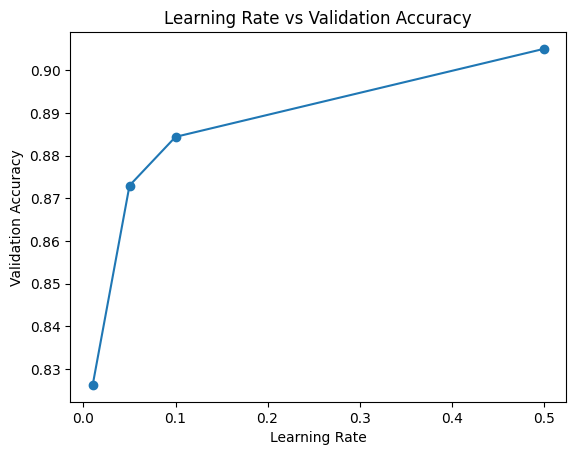

In [49]:
plt.plot(
    [r["learning_rate"] for r in lr_results],
    [r["val_accuracy"] for r in lr_results],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate vs Validation Accuracy")

plt.show()

Uh the plot is a bit off

### Observation: Learning Rate Trend

The initial learning-rate experiment produced an unexpected trend: larger learning rates consistently achieved higher validation accuracy within the tested range.

This does not necessarily indicate an error.

A likely explanation is that the tested learning rates were still below the point where training becomes unstable. Since every configuration used the same number of iterations, smaller learning rates may simply have learned too slowly.

Therefore, the initial experiment does not yet reveal the upper useful range of the learning rate.

To investigate further, we extend the experiment to larger learning rates and observe when performance stops improving or training becomes unstable.

In [50]:
import time

extended_learning_rates = [
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0
]

extended_lr_results = []

for lr in extended_learning_rates:
    start_time = time.perf_counter()

    W_exp, b_exp, loss_history_exp = train_softmax_regression(
        X_train,
        y_train,
        n_classes=10,
        learning_rate=lr,
        n_iterations=300
    )

    elapsed_time = time.perf_counter() - start_time

    y_val_pred_exp = predict(X_val, W_exp, b_exp)
    val_acc = accuracy(y_val, y_val_pred_exp)

    extended_lr_results.append({
        "learning_rate": lr,
        "val_accuracy": val_acc,
        "final_loss": loss_history_exp[-1],
        "time": elapsed_time
    })

    print(
        f"Learning rate: {lr:<5} | "
        f"Val accuracy: {val_acc:.4f} | "
        f"Final loss: {loss_history_exp[-1]:.4f} | "
        f"Time: {elapsed_time:.2f} s"
    )

Learning rate: 0.01  | Val accuracy: 0.8263 | Final loss: 1.0002 | Time: 168.83 s
Learning rate: 0.05  | Val accuracy: 0.8730 | Final loss: 0.5323 | Time: 179.30 s
Learning rate: 0.1   | Val accuracy: 0.8844 | Final loss: 0.4390 | Time: 171.79 s
Learning rate: 0.25  | Val accuracy: 0.8972 | Final loss: 0.3618 | Time: 172.44 s
Learning rate: 0.5   | Val accuracy: 0.9050 | Final loss: 0.3234 | Time: 169.21 s
Learning rate: 1.0   | Val accuracy: 0.9134 | Final loss: 0.2955 | Time: 169.94 s
Learning rate: 2.0   | Val accuracy: 0.9147 | Final loss: 0.2776 | Time: 167.86 s
Learning rate: 5.0   | Val accuracy: 0.7721 | Final loss: 2.4966 | Time: 169.19 s
Learning rate: 10.0  | Val accuracy: 0.7258 | Final loss: 4.1707 | Time: 168.63 s


In [51]:
print(
    f"{'Learning Rate':<16}"
    f"{'Val Accuracy':<16}"
    f"{'Final Loss':<14}"
    f"{'Time (s)':<12}"
)

for r in extended_lr_results:
    print(
        f"{r['learning_rate']:<16}"
        f"{r['val_accuracy']:<16.4f}"
        f"{r['final_loss']:<14.4f}"
        f"{r['time']:<12.2f}"
    )

Learning Rate   Val Accuracy    Final Loss    Time (s)    
0.01            0.8263          1.0002        168.83      
0.05            0.8730          0.5323        179.30      
0.1             0.8844          0.4390        171.79      
0.25            0.8972          0.3618        172.44      
0.5             0.9050          0.3234        169.21      
1.0             0.9134          0.2955        169.94      
2.0             0.9147          0.2776        167.86      
5.0             0.7721          2.4966        169.19      
10.0            0.7258          4.1707        168.63      


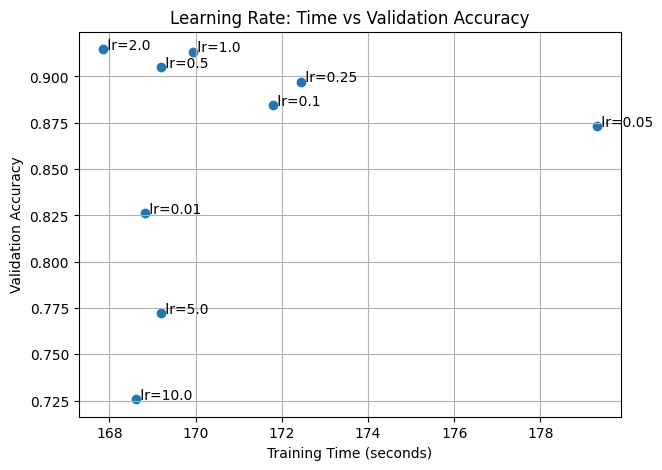

In [55]:
plt.figure(figsize=(7, 5))

times = [r["time"] for r in extended_lr_results]
accuracies = [r["val_accuracy"] for r in extended_lr_results]

plt.scatter(times, accuracies)

for r in extended_lr_results:
    plt.text(
        r["time"],
        r["val_accuracy"],
        f" lr={r['learning_rate']}"
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate: Time vs Validation Accuracy")
plt.grid(True)

plt.show()

### Analysis of the Extended Learning-Rate Experiment

The experiment shows a clear trend from learning rate $0.01$ to approximately $2.0$.

As the learning rate increases within this range:

- validation accuracy increases
- final training loss decreases
- training time remains approximately similar

For example:

- $\eta = 0.01$ reaches 82.63% validation accuracy with loss 1.0002
- $\eta = 0.5$ reaches 90.50% validation accuracy with loss 0.3234
- $\eta = 2.0$ reaches 91.47% validation accuracy with loss 0.2776

This suggests that the smaller learning rates are still converging too slowly within the fixed budget of 300 iterations.

All configurations perform the same number of full-batch iterations, so changing the learning rate does not substantially change the amount of computation performed.

The observed runtimes remain in a similar range of approximately 168–179 seconds.

Therefore, the main advantage of increasing the learning rate from $0.01$ to $2.0$ is faster optimization convergence rather than faster individual iterations.

### Instability at Large Learning Rates

The trend changes significantly when the learning rate becomes very large.

At:

$$ \eta = 5.0 $$

validation accuracy falls sharply to:

$$ 77.21\% $$

while the final loss increases to:

$$ 2.4966 $$

At:

$$ \eta = 10.0 $$

the behavior becomes even worse in this run:

$$ \text{Validation Accuracy} = 72.58\% $$

$$ \text{Final Loss} = 4.1707 $$

These results indicate that the optimization has entered an unstable region.

With a very large learning rate, Gradient Descent can make parameter updates that are too large.

Instead of gradually moving toward a low-loss solution, an update may overshoot useful parameter values.

Repeated overshooting can cause the parameters to move through poor regions of the loss surface rather than converge.

### Reproducibility at Very Large Learning Rates

An earlier run with $\eta = 10.0$ produced substantially different results, while the results for smaller learning rates remained unchanged.

This is another indication that $\eta = 10.0$ is operating in an unstable optimization regime.

The model and dataset split are deterministic, so stable learning-rate configurations should produce essentially the same accuracy and loss when rerun.

However, floating-point matrix computations can contain extremely small numerical differences between executions.

Normally these differences are negligible.

When the learning rate is excessively large, very small numerical differences can be amplified by large parameter updates and eventually lead to noticeably different optimization trajectories.

Therefore, the behavior at $\eta = 10.0$ should not be considered reliable or stable.

### Accuracy and Cross Entropy

Accuracy and Cross Entropy measure different aspects of model performance.

Validation accuracy only checks whether the class with the highest predicted probability is correct.

Cross Entropy also considers the probability assigned to the correct class.

Therefore, both metrics are useful when evaluating the optimization process.

In the stable learning-rate range, increasing the learning rate up to $\eta = 2.0$ improves both metrics:

- validation accuracy increases
- Cross Entropy loss decreases

At $\eta = 5.0$ and $\eta = 10.0$, both metrics deteriorate sharply.

This provides stronger evidence that these learning rates are too large for stable training.

### Conclusion

The extended experiment suggests three learning-rate regions.

**Small learning rates ($0.01$–$0.1$)**

Training is stable, but convergence is slow within the fixed 300-iteration budget.

**Moderate learning rates ($0.25$–$2.0$)**

The model converges substantially faster and achieves progressively better validation performance.

Among the tested values, $\eta = 2.0$ achieves the strongest result:

$$ \text{Validation Accuracy} = 91.47\% $$

$$ \text{Final Loss} = 0.2776 $$

**Very large learning rates ($5.0$ and $10.0$)**

Optimization becomes unstable.

Both validation accuracy and training loss deteriorate substantially, and the result at $\eta = 10.0$ is sensitive enough that different runs can produce noticeably different outcomes.

Therefore, $\eta = 2.0$ is selected as the learning rate for the following experiments.

### Note on Longer Convergence Testing

A longer experiment comparing low and high learning rates was considered.

However, full-batch Softmax Regression on MNIST is computationally expensive, and the extended experiment already demonstrates the main trend clearly.

The results are sufficient to show that:

- small learning rates converge slowly under a fixed iteration budget
- moderate learning rates converge much more efficiently
- excessively large learning rates cause unstable optimization

Therefore, no additional long-duration convergence experiment was performed.

### Experiment 2 — Number of Iterations

The number of iterations determines how many complete gradient descent updates are performed.

Too few iterations may stop training before the model has converged.

More iterations may improve performance, although improvements eventually become smaller.

We will keep the learning rate fixed and compare several training lengths.

In [62]:
best_lr_result = max(
    extended_lr_results,
    key=lambda result: result["val_accuracy"]
)

best_learning_rate = best_lr_result["learning_rate"]

print("Best learning rate:", best_learning_rate)

Best learning rate: 2.0


### Selected Learning Rate

Based on the extended learning-rate experiment, the best stable learning rate is:

$$ \eta = 2.0 $$

This value achieved the highest validation accuracy among the stable configurations and the lowest final loss before optimization became unstable at larger learning rates.

Therefore, $\eta = 2.0$ is used for the iteration experiment.

In [63]:
%%time

iteration_values = [100, 300, 500, 1000]

iteration_results = []

for n_iterations in iteration_values:
    W_exp, b_exp, loss_history_exp = train_softmax_regression(
        X_train,
        y_train,
        n_classes=10,
        learning_rate=best_learning_rate,
        n_iterations=n_iterations
    )

    y_val_pred_exp = predict(X_val, W_exp, b_exp)

    val_acc = accuracy(y_val, y_val_pred_exp)

    iteration_results.append({
        "n_iterations": n_iterations,
        "val_accuracy": val_acc,
        "final_loss": loss_history_exp[-1],
        "W": W_exp,
        "b": b_exp
    })

    print(
        f"Iterations: {n_iterations} | "
        f"Validation accuracy: {val_acc:.4f} | "
        f"Final loss: {loss_history_exp[-1]:.4f}"
    )

Iterations: 100 | Validation accuracy: 0.8309 | Final loss: 0.5191
Iterations: 300 | Validation accuracy: 0.9147 | Final loss: 0.2776
Iterations: 500 | Validation accuracy: 0.9135 | Final loss: 0.2729
Iterations: 1000 | Validation accuracy: 0.9196 | Final loss: 0.2493
CPU times: user 23min 36s, sys: 3min 54s, total: 27min 31s
Wall time: 18min 2s


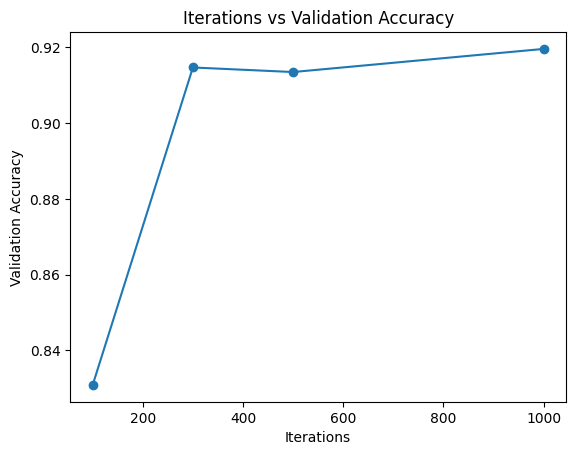

In [64]:
plt.plot(
    [r["n_iterations"] for r in iteration_results],
    [r["val_accuracy"] for r in iteration_results],
    marker="o"
)

plt.xlabel("Iterations")
plt.ylabel("Validation Accuracy")
plt.title("Iterations vs Validation Accuracy")

plt.show()

### Experiment 3 — Batch Size: Performance vs Training Efficiency

Mini-batch Gradient Descent updates the model after processing only part of the training set.

For a dataset containing $N$ samples, the approximate number of parameter updates per epoch is:

$$ \text{updates per epoch} = \frac{N}{\text{batch size}} $$

Therefore, smaller batches perform many more parameter updates:

- batch size 32: many small updates
- batch size 128: fewer updates
- batch size 512: even fewer updates
- batch size 2048: relatively few large updates

This creates a possible trade-off.

Smaller batches may provide more frequent optimization updates and potentially stronger validation performance.

Larger batches require fewer update steps and may therefore train faster.

This experiment compares:

- validation accuracy
- final training loss
- pure training time

To measure runtime fairly, expensive full-dataset evaluation is performed only after training and is not included in the training timer.

In [77]:
def train_softmax_minibatch_timed(
    X,
    y,
    n_classes=10,
    learning_rate=0.1,
    n_epochs=50,
    batch_size=128,
    seed=42
):
    n_samples, n_features = X.shape

    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)

    rng = np.random.default_rng(seed)

    start_time = time.perf_counter()

    for epoch in range(n_epochs):
        indices = rng.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            Z = X_batch @ W + b
            P = softmax(Z)

            dW, db = compute_gradients(
                X_batch,
                y_batch,
                P,
                n_classes
            )

            W, b = update_parameters(
                W,
                b,
                dW,
                db,
                learning_rate
            )

    training_time = time.perf_counter() - start_time

    return W, b, training_time

Learning rate = 2.0 from the full batch is a bit aggressive and might not be optimal for mini batches. So we're using 0.1

In [78]:
%%time

batch_sizes = [32, 128, 512, 2048, 50000]

batch_results = []

for batch_size in batch_sizes:
    W_exp, b_exp, training_time = train_softmax_minibatch_timed(
        X_train,
        y_train,
        n_classes=10,
        learning_rate=0.1,
        n_epochs=50,
        batch_size=batch_size
    )

    # Evaluation happens AFTER timing
    train_P = predict_proba(X_train, W_exp, b_exp)
    final_loss = cross_entropy(y_train, train_P)

    y_val_pred_exp = predict(X_val, W_exp, b_exp)
    val_acc = accuracy(y_val, y_val_pred_exp)

    updates_per_epoch = int(
        np.ceil(len(X_train) / batch_size)
    )

    batch_results.append({
        "batch_size": batch_size,
        "updates_per_epoch": updates_per_epoch,
        "time": training_time,
        "val_accuracy": val_acc,
        "final_loss": final_loss
    })

    print(
        f"Batch: {batch_size:<6} | "
        f"Updates/epoch: {updates_per_epoch:<5} | "
        f"Time: {training_time:.2f}s | "
        f"Val acc: {val_acc:.4f} | "
        f"Loss: {final_loss:.4f}"
    )

Batch: 32     | Updates/epoch: 1563  | Time: 24.49s | Val acc: 0.9205 | Loss: 0.2312
Batch: 128    | Updates/epoch: 391   | Time: 29.68s | Val acc: 0.9201 | Loss: 0.2505
Batch: 512    | Updates/epoch: 98    | Time: 24.90s | Val acc: 0.9162 | Loss: 0.2806
Batch: 2048   | Updates/epoch: 25    | Time: 21.87s | Val acc: 0.9033 | Loss: 0.3323
Batch: 50000  | Updates/epoch: 1     | Time: 34.25s | Val acc: 0.8431 | Loss: 0.7954
CPU times: user 3min 5s, sys: 14.7 s, total: 3min 20s
Wall time: 2min 16s


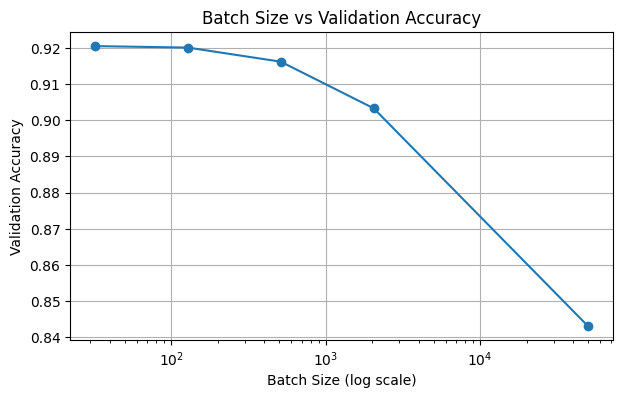

In [79]:
plt.figure(figsize=(7, 4))

plt.plot(
    [r["batch_size"] for r in batch_results],
    [r["val_accuracy"] for r in batch_results],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Batch Size (log scale)")
plt.ylabel("Validation Accuracy")
plt.title("Batch Size vs Validation Accuracy")
plt.grid(True)

plt.show()

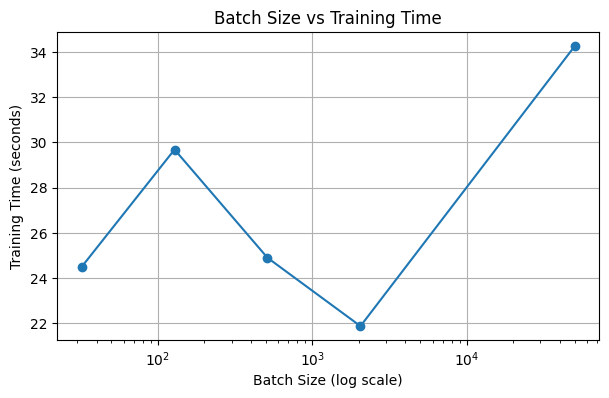

In [80]:
plt.figure(figsize=(7, 4))

plt.plot(
    [r["batch_size"] for r in batch_results],
    [r["time"] for r in batch_results],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Batch Size (log scale)")
plt.ylabel("Training Time (seconds)")
plt.title("Batch Size vs Training Time")
plt.grid(True)

plt.show()

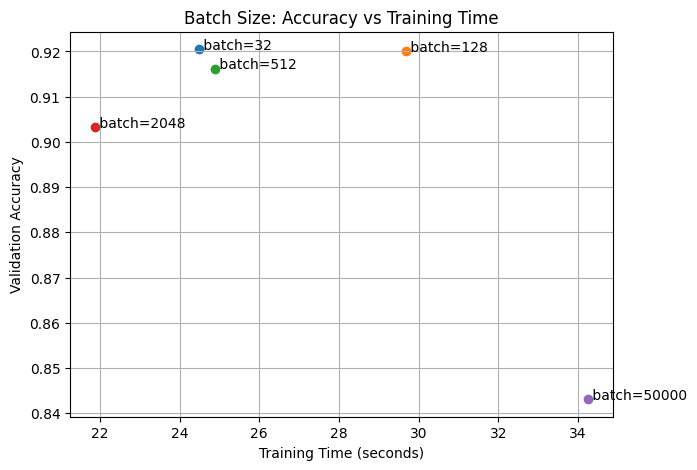

In [81]:
plt.figure(figsize=(7, 5))

for r in batch_results:
    plt.scatter(
        r["time"],
        r["val_accuracy"]
    )

    plt.text(
        r["time"],
        r["val_accuracy"],
        f" batch={r['batch_size']}"
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("Validation Accuracy")
plt.title("Batch Size: Accuracy vs Training Time")
plt.grid(True)

plt.show()

### Batch Size Analysis

The experiment shows a clear trade-off between batch size, optimization behavior, and training efficiency.

The smallest tested batch size achieved the highest validation accuracy:

- batch size 32: 92.05%
- batch size 128: 92.01%
- batch size 512: 91.62%
- batch size 2048: 90.33%
- full batch 50000: 84.31%

As batch size increases, the number of parameter updates per epoch decreases substantially.

For example:

- batch size 32 performs approximately 1563 updates per epoch
- batch size 512 performs approximately 98 updates per epoch
- batch size 2048 performs approximately 25 updates per epoch
- full-batch training performs only 1 update per epoch

The smaller batches therefore update the model much more frequently during each pass through the dataset.

This appears to improve optimization performance in the current experiment, with batch size 32 achieving the highest validation accuracy and one of the lowest final losses.

### Training Time

Training time does not decrease perfectly as batch size increases.

Among the mini-batch configurations, batch size 2048 was the fastest:

$$ 21.87\text{ s} $$

while batch size 32 required:

$$ 24.49\text{ s} $$

The timing differences are influenced by more than just the number of parameter updates.

Matrix multiplication efficiency, memory access, Python loop overhead, and the execution environment also affect runtime.

For example, batch size 128 was slower than both batch size 32 and 512 despite performing fewer updates than batch size 32.

The full-batch configuration was also relatively slow at 34.25 seconds.

Although it performs only one parameter update per epoch, each update requires processing the entire training dataset in one large matrix operation.

Therefore, fewer updates do not necessarily imply lower wall-clock training time.

### Accuracy–Efficiency Trade-Off

The experiment demonstrates a clear trade-off.

Smaller batches provide more frequent parameter updates and achieved better validation performance.

Larger mini-batches require fewer updates and can reduce training time, but validation accuracy decreases as the batch size becomes very large.

In this experiment:

- batch size 32 achieved the highest validation accuracy at 92.05%
- batch size 2048 achieved the fastest mini-batch training time at 21.87 seconds
- full-batch training produced both the lowest validation accuracy and one of the longest runtimes

Therefore, batch size 32 provides the strongest predictive performance, while larger batches such as 2048 provide greater computational efficiency.

### Final Model Selection

The previous experiments optimized different parts of the training process.

For **full-batch Gradient Descent**:

- Experiment 1 selected the learning rate.
- Experiment 2 selected the number of iterations.

For **mini-batch Gradient Descent**:

- Experiment 3 compared batch sizes using a learning rate suitable for mini-batch training.

These settings should not be mixed directly because learning rate and batch size interact with each other.

Therefore, we construct two candidate models:

1. Best full-batch configuration
2. Best mini-batch configuration

The candidates are first compared using validation accuracy.

The test set remains unused until the final model has been selected.

In [82]:
best_iteration_result = max(
    iteration_results,
    key=lambda result: result["val_accuracy"]
)

best_n_iterations = best_iteration_result["n_iterations"]

print("Selected learning rate:", best_learning_rate)
print("Selected iterations:", best_n_iterations)

Selected learning rate: 2.0
Selected iterations: 1000


In [83]:
start_time = time.perf_counter()

W_full, b_full, full_loss_history = train_softmax_regression(
    X_train,
    y_train,
    n_classes=10,
    learning_rate=best_learning_rate,
    n_iterations=best_n_iterations
)

full_training_time = time.perf_counter() - start_time

full_val_pred = predict(X_val, W_full, b_full)
full_val_accuracy = accuracy(y_val, full_val_pred)

print("Full-batch validation accuracy:", full_val_accuracy)
print("Full-batch final loss:", full_loss_history[-1])
print("Full-batch training time:", full_training_time)

Full-batch validation accuracy: 0.9196
Full-batch final loss: 0.24925096540841427
Full-batch training time: 588.9861618640007


The full-batch candidate uses the best learning rate and iteration count found in Experiments 1 and 2.

This represents the strongest configuration found for the original full-batch Softmax Regression training procedure.

In [85]:
best_batch_size = max(
    batch_results,
    key=lambda result: result["val_accuracy"]
)["batch_size"]

print("Selected batch size:", best_batch_size)

Selected batch size: 32


In [86]:
mini_learning_rate = 0.1
mini_epochs = 50

W_mini, b_mini, mini_training_time = train_softmax_minibatch_timed(
    X_train,
    y_train,
    n_classes=10,
    learning_rate=mini_learning_rate,
    n_epochs=mini_epochs,
    batch_size=best_batch_size
)

mini_train_P = predict_proba(
    X_train,
    W_mini,
    b_mini
)

mini_final_loss = cross_entropy(
    y_train,
    mini_train_P
)

mini_val_pred = predict(
    X_val,
    W_mini,
    b_mini
)

mini_val_accuracy = accuracy(
    y_val,
    mini_val_pred
)

print("Mini-batch validation accuracy:", mini_val_accuracy)
print("Mini-batch final loss:", mini_final_loss)
print("Mini-batch training time:", mini_training_time)

Mini-batch validation accuracy: 0.9205
Mini-batch final loss: 0.2312313073433979
Mini-batch training time: 24.988918271999864


### Full-Batch vs Mini-Batch

The two candidate models use the same Softmax Regression architecture.

The only difference is the optimization strategy.

We compare:

- validation accuracy
- final training loss
- training time

Validation accuracy is the primary criterion for final model selection.

Training loss and runtime provide additional information about optimization behavior and computational efficiency.

In [87]:
final_candidates = [
    {
        "method": "Full-batch",
        "val_accuracy": full_val_accuracy,
        "final_loss": full_loss_history[-1],
        "training_time": full_training_time,
        "W": W_full,
        "b": b_full
    },
    {
        "method": "Mini-batch",
        "val_accuracy": mini_val_accuracy,
        "final_loss": mini_final_loss,
        "training_time": mini_training_time,
        "W": W_mini,
        "b": b_mini
    }
]

print(
    f"{'Method':<15}"
    f"{'Val Accuracy':<16}"
    f"{'Final Loss':<14}"
    f"{'Time (s)':<12}"
)

for candidate in final_candidates:
    print(
        f"{candidate['method']:<15}"
        f"{candidate['val_accuracy']:<16.4f}"
        f"{candidate['final_loss']:<14.4f}"
        f"{candidate['training_time']:<12.2f}"
    )

Method         Val Accuracy    Final Loss    Time (s)    
Full-batch     0.9196          0.2493        588.99      
Mini-batch     0.9205          0.2312        24.99       


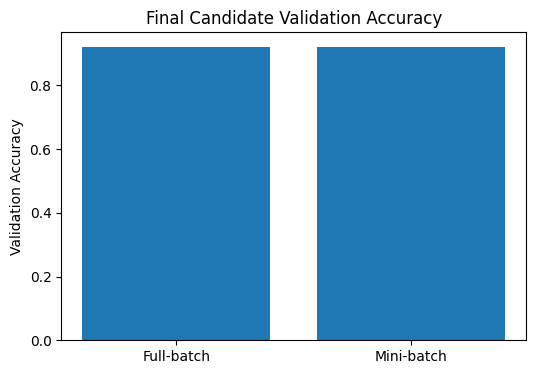

In [88]:
methods = [c["method"] for c in final_candidates]
accuracies = [c["val_accuracy"] for c in final_candidates]

plt.figure(figsize=(6, 4))

plt.bar(methods, accuracies)

plt.ylabel("Validation Accuracy")
plt.title("Final Candidate Validation Accuracy")

plt.show()

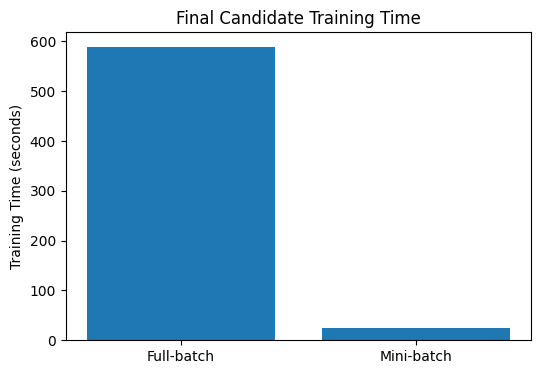

In [89]:
times = [c["training_time"] for c in final_candidates]

plt.figure(figsize=(6, 4))

plt.bar(methods, times)

plt.ylabel("Training Time (seconds)")
plt.title("Final Candidate Training Time")

plt.show()

In [90]:
best_candidate = max(
    final_candidates,
    key=lambda candidate: candidate["val_accuracy"]
)

final_W = best_candidate["W"]
final_b = best_candidate["b"]

print("Selected final model:", best_candidate["method"])
print(
    "Validation accuracy:",
    best_candidate["val_accuracy"]
)

Selected final model: Mini-batch
Validation accuracy: 0.9205


### Final Test Evaluation

All hyperparameter selection was performed using the training and validation sets.

The test set has not been used to select the learning rate, iteration count, batch size, or optimization strategy.

After selecting the final model using validation accuracy, we evaluate it once on the test set.

This provides the final estimate of how well the Softmax Regression model generalizes to unseen MNIST images.

In [91]:
final_test_pred = predict(
    X_test,
    final_W,
    final_b
)

final_test_accuracy = accuracy(
    y_test,
    final_test_pred
)

print("Final model:", best_candidate["method"])
print("Validation accuracy:", best_candidate["val_accuracy"])
print("Test accuracy:", final_test_accuracy)

Final model: Mini-batch
Validation accuracy: 0.9205
Test accuracy: 0.9254


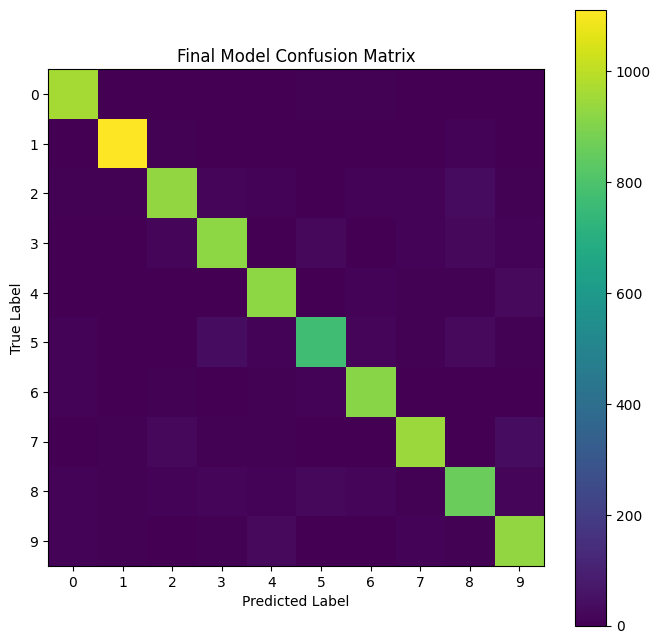

In [92]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(8, 8))

plt.imshow(final_cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Model Confusion Matrix")

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()

plt.show()

In [93]:
print("Original baseline test accuracy:", test_accuracy)
print("Final model test accuracy       :", final_test_accuracy)

print(
    "Improvement:",
    final_test_accuracy - test_accuracy
)

Original baseline test accuracy: 0.9098
Final model test accuracy       : 0.9254
Improvement: 0.015599999999999947


### Final Experiment Summary

The experiments progressively investigated three optimization choices:

1. learning rate
2. number of training iterations
3. batch size

The learning-rate experiment showed that very small learning rates converged slowly under a fixed iteration budget, while excessively large learning rates caused unstable optimization.

The iteration experiment examined how additional Gradient Descent updates affected validation performance.

The batch-size experiment demonstrated a trade-off between update frequency, validation performance, and computational efficiency.

Finally, the strongest full-batch and mini-batch configurations were compared using validation accuracy.

The final model was selected before examining test performance.

This experimental workflow separates:

- model architecture
- optimization choices
- model selection
- final evaluation

The underlying classifier remained Softmax Regression throughout all experiments.

## Module 10 — Conclusion

This notebook extended binary Logistic Regression into **Softmax Regression** for multiclass classification on MNIST.

The main changes were:

- one logit became 10 logits
- the weight vector became a weight matrix
- the scalar bias became a bias vector
- Sigmoid was replaced by Softmax
- Binary Cross Entropy was replaced by Multiclass Cross Entropy
- threshold-based prediction was replaced by `argmax`
- the scalar error term became a multiclass error matrix

The main ideas reused from Logistic Regression were:

- linear transformation
- gradient-based optimization
- backpropagation structure
- parameter updates
- train / validation / test separation
- accuracy-based evaluation
- numerical gradient checking

The final Softmax Regression pipeline is:

```text
MNIST image
    ↓
Flatten to 784 features
    ↓
Linear transformation
    ↓
10 logits
    ↓
Softmax
    ↓
10 class probabilities
    ↓
Multiclass Cross Entropy
    ↓
Backpropagation
    ↓
Gradient Descent
    ↓
Updated parameters